# TP Python 1 : Rappels Python

**Géoinformatique II — Université de Lausanne**





---
## 1. Rappels Python

### 1.1 Types de données fondamentaux

Python propose plusieurs types de données de base. Le type d'une variable est
déterminé automatiquement à l'affectation — pas besoin de le déclarer comme en C.

| Type | Exemple | Description |
|------|---------|-------------|
| `int` | `42` | Nombre entier |
| `float` | `3.14` | Nombre décimal |
| `str` | `"Lausanne"` | Chaîne de caractères |
| `bool` | `True` | Valeur logique |


In [2]:
# --- Types de base ---
altitude = 1642          # int   : altitude du Cervin en mètres
temperature = -12.5      # float : température en degrés Celsius
ville = "Lausanne"       # str   : nom d'une ville
est_lacustre = True      # bool  : la ville est-elle au bord d'un lac ?

# La fonction type() permet de connaître le type d'une variable
print(type(altitude))
print(type(temperature))
print(type(ville))
print(type(est_lacustre))

# Affichage formaté avec f-strings (Python 3.6+)
print(f"{ville} se trouve à {altitude} m d'altitude.")
print(f"Température : {temperature} °C, ville lacustre : {est_lacustre}")


<class 'int'>
<class 'float'>
<class 'str'>
<class 'bool'>
Lausanne se trouve à 1642 m d'altitude.
Température : -12.5 °C, ville lacustre : True


### 1.2 Listes

Une **liste** est une collection ordonnée et modifiable d'éléments.
Elle peut contenir des éléments de types différents.


In [3]:
# Création d'une liste
cantons = ["Vaud", "Genève", "Valais", "Fribourg", "Berne"]

# Longueur
print(f"Nombre de cantons : {len(cantons)}")

# Indexation (commence à 0 !)
print(f"Premier canton  : {cantons[0]}")
print(f"Dernier canton  : {cantons[-1]}")

# Tranche (slice) : cantons[début:fin] — fin non incluse
print(f"Deux premiers   : {cantons[0:2]}")
print(f"Trois derniers  : {cantons[-3:]}")

# Modification
cantons.append("Neuchâtel")    # ajoute à la fin
cantons[1] = "GE"              # modifie un élément
print(cantons)

# Test d'appartenance
print("Vaud" in cantons)       # True
print("Zurich" in cantons)     # False


Nombre de cantons : 5
Premier canton  : Vaud
Dernier canton  : Berne
Deux premiers   : ['Vaud', 'Genève']
Trois derniers  : ['Valais', 'Fribourg', 'Berne']
['Vaud', 'GE', 'Valais', 'Fribourg', 'Berne', 'Neuchâtel']
True
False


### 1.3 Dictionnaires

Un **dictionnaire** associe des *clés* à des *valeurs*. C'est l'équivalent
d'une table attributaire dans un SIG : chaque clé est un nom de champ.


In [4]:
# Un dictionnaire représentant une entité géographique (commune)
lausanne = {
    "nom": "Lausanne",
    "canton": "Vaud",
    "population": 139408,
    "superficie_km2": 41.37,
    "chef_lieu": True,
    "altitude_m": 455
}

# Accès à une valeur par sa clé
print(lausanne["nom"])
print(lausanne["population"])

# Modification et ajout de clés
lausanne["altitude_m"] = 496            # mise à jour
lausanne["crs"] = "EPSG:2056"          # nouvelle clé
print(lausanne)

# Méthodes utiles
print(lausanne.keys())                  # toutes les clés
print(lausanne.values())                # toutes les valeurs

# Test d'existence d'une clé
if "population" in lausanne:
    print(f"Population : {lausanne['population']}")


Lausanne
139408
{'nom': 'Lausanne', 'canton': 'Vaud', 'population': 139408, 'superficie_km2': 41.37, 'chef_lieu': True, 'altitude_m': 496, 'crs': 'EPSG:2056'}
dict_keys(['nom', 'canton', 'population', 'superficie_km2', 'chef_lieu', 'altitude_m', 'crs'])
dict_values(['Lausanne', 'Vaud', 139408, 41.37, True, 496, 'EPSG:2056'])
Population : 139408


### 1.4 Boucles

Les **boucles** permettent de répéter des opérations. En géomatique, elles sont
très utiles pour traiter une liste de couches, de fichiers ou d'entités.


In [5]:
# Boucle for sur une liste
pays_romands = ["Suisse", "France", "Belgique", "Luxembourg"]
for pays in pays_romands:
    print(f"  - {pays}")

# Boucle for avec range()
print("\nComptage :")
for i in range(5):              # 0, 1, 2, 3, 4
    print(f"  i = {i}")

# Boucle for avec enumerate() — fournit index ET valeur
cantons = ["VD", "GE", "VS", "FR"]
print("\nIndex + valeur :")
for i, canton in enumerate(cantons):
    print(f"  [{i}] {canton}")


  - Suisse
  - France
  - Belgique
  - Luxembourg

Comptage :
  i = 0
  i = 1
  i = 2
  i = 3
  i = 4

Index + valeur :
  [0] VD
  [1] GE
  [2] VS
  [3] FR


In [6]:
# Boucle while
compteur = 0
while compteur < 3:
    print(f"Itération {compteur}")
    compteur += 1

# Compréhension de liste (list comprehension) — très idiomatique en Python
altitudes_m = [4478, 4634, 3970, 4165]
altitudes_ft = [round(a * 3.28084) for a in altitudes_m]
print("\nAltitudes en pieds :", altitudes_ft)

# Avec condition
hauts_sommets = [a for a in altitudes_m if a > 4200]
print("Sommets > 4200 m :", hauts_sommets)


Itération 0
Itération 1
Itération 2

Altitudes en pieds : [14692, 15203, 13025, 13665]
Sommets > 4200 m : [4478, 4634]


### 1.5 Fonctions

Une **fonction** regroupe du code réutilisable. En géomatique, on écrit souvent
des fonctions pour calculer des indicateurs ou transformer des données.


In [7]:
# Définition d'une fonction simple
import math

def surface_cercle(rayon_m):
    """Calcule la superficie d'un cercle en km²."""
    surface_m2 = math.pi * rayon_m ** 2
    return surface_m2 / 1_000_000       # conversion m² → km²

# Appel
rayon = 5000                           # 5 km
s = surface_cercle(rayon)
print(f"Surface d'un cercle de rayon {rayon} m : {s:.4f} km²")


# Fonction avec plusieurs paramètres et valeur par défaut
def densite_population(population, superficie_km2, unite="hab/km²"):
    """Retourne la densité de population."""
    densite = population / superficie_km2
    return f"{densite:.1f} {unite}"

print(densite_population(139408, 41.37))
print(densite_population(521000, 87.88, unite="personnes/km²"))


Surface d'un cercle de rayon 5000 m : 78.5398 km²
3369.8 hab/km²
5928.5 personnes/km²


---
## 2. NumPy — tableaux et calcul numérique

**NumPy** est la bibliothèque de référence pour le calcul numérique en Python.
Un tableau NumPy (`ndarray`) stocke des données numériques de manière très
efficace et permet des opérations vectorisées (sans boucle explicite).

> 🔗 **Lien avec les SIG** : les bandes raster, les coordonnées et les matrices
> de transformation sont naturellement représentées sous forme de tableaux NumPy.


In [8]:
import numpy as np

# --- Création de tableaux ---
a = np.array([1, 2, 3, 4, 5])          # à partir d'une liste Python
b = np.arange(0, 100, 10)              # de 0 à 90, pas de 10
c = np.linspace(0, 1, 6)              # 6 valeurs régulièrement espacées entre 0 et 1
d = np.zeros(4)                        # tableau de zéros
e = np.ones((2, 3))                    # tableau 2D rempli de 1

print("a =", a)
print("b =", b)
print("c =", c)
print("d (zéros) =", d)
print("e (2×3 de 1) =\n", e)


a = [1 2 3 4 5]
b = [ 0 10 20 30 40 50 60 70 80 90]
c = [0.  0.2 0.4 0.6 0.8 1. ]
d (zéros) = [0. 0. 0. 0.]
e (2×3 de 1) =
 [[1. 1. 1.]
 [1. 1. 1.]]


In [9]:
# --- Opérations vectorisées (s'appliquent à chaque élément) ---
coords_deg = np.array([6.63, 6.85, 7.05, 7.25])    # longitudes en degrés

# Conversion degrés → radians, sans boucle
coords_rad = np.radians(coords_deg)
print("Degrés  :", coords_deg)
print("Radians :", np.round(coords_rad, 4))

# Opérations mathématiques
print("× 2 :", coords_deg * 2)
print("+ 1 :", coords_deg + 1)
print("²   :", coords_deg ** 2)


Degrés  : [6.63 6.85 7.05 7.25]
Radians : [0.1157 0.1196 0.123  0.1265]
× 2 : [13.26 13.7  14.1  14.5 ]
+ 1 : [7.63 7.85 8.05 8.25]
²   : [43.9569 46.9225 49.7025 52.5625]


In [10]:
# --- Indexation et slicing ---
elev = np.array([375, 455, 520, 612, 728, 890, 1105, 1342])

print("Premier élément  :", elev[0])
print("Dernier élément  :", elev[-1])
print("Éléments 2 à 5   :", elev[2:5])       # indices 2, 3, 4
print("Un sur deux      :", elev[::2])

# Indexation booléenne (masque) — très puissant
masque = elev > 700
print("Éléments > 700 m :", elev[masque])
print("Nombre d'éléments > 700 m :", masque.sum())


Premier élément  : 375
Dernier élément  : 1342
Éléments 2 à 5   : [520 612 728]
Un sur deux      : [ 375  520  728 1105]
Éléments > 700 m : [ 728  890 1105 1342]
Nombre d'éléments > 700 m : 4


In [11]:
# --- Statistiques descriptives ---
precipitations_mm = np.array([54, 62, 71, 68, 82, 93, 78, 74, 65, 59, 61, 55])
mois = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

print(f"Total annuel  : {precipitations_mm.sum()} mm")
print(f"Moyenne mensuelle : {precipitations_mm.mean():.1f} mm")
print(f"Écart-type    : {precipitations_mm.std():.1f} mm")
print(f"Min (mois)    : {precipitations_mm.min()} mm — {mois[precipitations_mm.argmin()]}")
print(f"Max (mois)    : {precipitations_mm.max()} mm — {mois[precipitations_mm.argmax()]}")


Total annuel  : 822 mm
Moyenne mensuelle : 68.5 mm
Écart-type    : 11.2 mm
Min (mois)    : 54 mm — Jan
Max (mois)    : 93 mm — Jun


---
## 3. Matplotlib — visualisation de données

**Matplotlib** est la bibliothèque de visualisation standard en Python.
Elle permet de créer des graphiques publiables en quelques lignes de code.


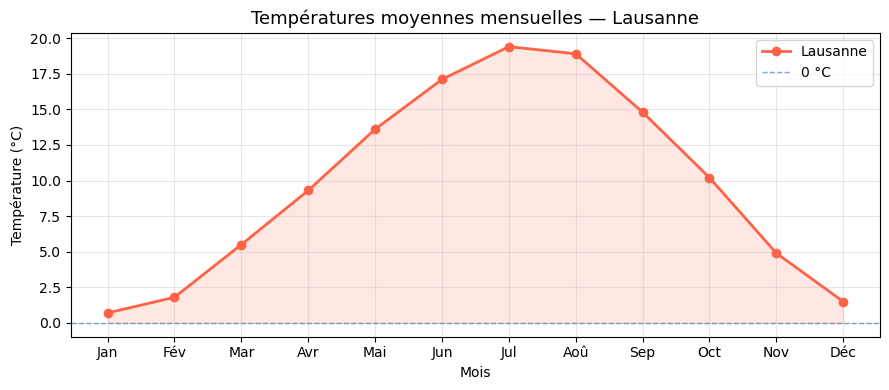

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# --- Graphique linéaire ---
mois = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
t_lausanne = [0.7, 1.8, 5.5, 9.3, 13.6, 17.1, 19.4, 18.9, 14.8, 10.2, 4.9, 1.5]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mois, t_lausanne, marker='o', color='tomato', linewidth=2, label='Lausanne')
ax.axhline(0, color='steelblue', linestyle='--', linewidth=1, alpha=0.7, label='0 °C')
ax.fill_between(mois, 0, t_lausanne, alpha=0.15, color='tomato')
ax.set_title('Températures moyennes mensuelles — Lausanne', fontsize=13)
ax.set_xlabel('Mois')
ax.set_ylabel('Température (°C)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


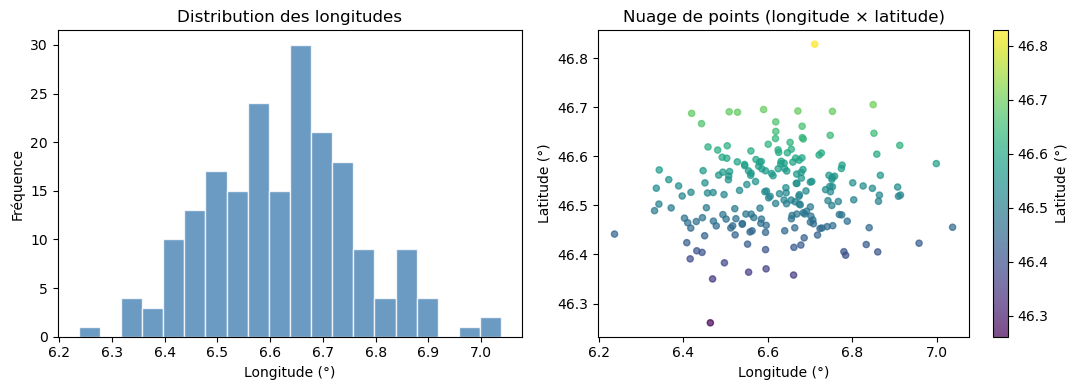

In [13]:
# --- Histogramme + nuage de points côte à côte ---
np.random.seed(42)
n_points = 200
lon = np.random.normal(6.63, 0.15, n_points)    # longitudes simulées (région Lausanne)
lat = np.random.normal(46.52, 0.08, n_points)   # latitudes simulées

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Histogramme
axes[0].hist(lon, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution des longitudes')
axes[0].set_xlabel('Longitude (°)')
axes[0].set_ylabel('Fréquence')

# Nuage de points
sc = axes[1].scatter(lon, lat, c=lat, cmap='viridis', s=20, alpha=0.7)
axes[1].set_title('Nuage de points (longitude × latitude)')
axes[1].set_xlabel('Longitude (°)')
axes[1].set_ylabel('Latitude (°)')
plt.colorbar(sc, ax=axes[1], label='Latitude (°)')

plt.tight_layout()
plt.show()


---
## 4. GeoPandas — premier contact

**GeoPandas** étend la bibliothèque Pandas pour travailler avec des données
**géospatiales vectorielles** (points, lignes, polygones).

Un `GeoDataFrame` ressemble à un tableau Pandas avec une colonne spéciale
`geometry` contenant les géométries de chaque entité.

**Parallèle QGIS** : un `GeoDataFrame` est l'équivalent d'une **couche vectorielle** dans QGIS.

Nous allons travailler avec le même fichier **`tp1.gpkg`** que nous avons manipulé dans QGIS.


In [31]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Chargement de la couche Cantons depuis le même GeoPackage utilisé dans QGIS au TP1
# Même fichier, même couche — mais maintenant accessible en Python !
cantons = gpd.read_file('tp1.gpkg', layer='Cantons')

# Exploration des premières lignes
print("Colonnes disponibles :")
print(cantons.columns.tolist())
print(f"\nType      : {type(cantons)}")
print(f"Dimensions : {cantons.shape[0]} lignes × {cantons.shape[1]} colonnes")
print()
cantons.head()


Colonnes disponibles :
['KT', 'AK', 'NAME', 'area', 'geometry']

Type      : <class 'geopandas.geodataframe.GeoDataFrame'>
Dimensions : 26 lignes × 5 colonnes



,KT,AK,NAME,area,geometry
0,1,ZH,Z�rich,1.661120e+09,"MULTIPOLYGON (((689073 283025, 689615 283093, ..."
1,2,BE,Bern,5.840584e+09,"MULTIPOLYGON (((575335 196135, 576162 196492, ..."
2,3,LU,Luzern,1.429278e+09,"MULTIPOLYGON (((675328 213188, 676178 212945, ..."
3,4,UR,Uri,1.057806e+09,"MULTIPOLYGON (((689986 200836, 690205 200840, ..."
4,5,SZ,Schwyz,8.517961e+08,"MULTIPOLYGON (((713825 230780, 714967 230597, ..."


In [32]:
# --- Explorer les attributs (≡ ouvrir la table attributaire dans QGIS) ---
print("Types de données :")
print(cantons.dtypes)
print()
# La colonne 'geometry' contient les géométries vectorielles
print("Type de géométrie :", cantons.geometry.geom_type.value_counts())


Types de données :
KT             int32
AK            object
NAME          object
area         float64
geometry    geometry
dtype: object

Type de géométrie : MultiPolygon    26
Name: count, dtype: int64


In [33]:
# --- CRS (Coordinate Reference System) ---
# Dans QGIS, tu as vu que les couches de tp1.gpkg utilisent le système suisse MN03
# Ce même code EPSG est accessible directement en Python
print("CRS du jeu de données :", cantons.crs)
print("Code EPSG             :", cantons.crs.to_epsg())
print("Unité de mesure       :", cantons.crs.axis_info[0].unit_name)
print("→ Les coordonnées sont en mètres (système suisse MN03 / CH1903)")


CRS du jeu de données : EPSG:21781
Code EPSG             : 21781
Unité de mesure       : metre
→ Les coordonnées sont en mètres (système suisse MN03 / CH1903)


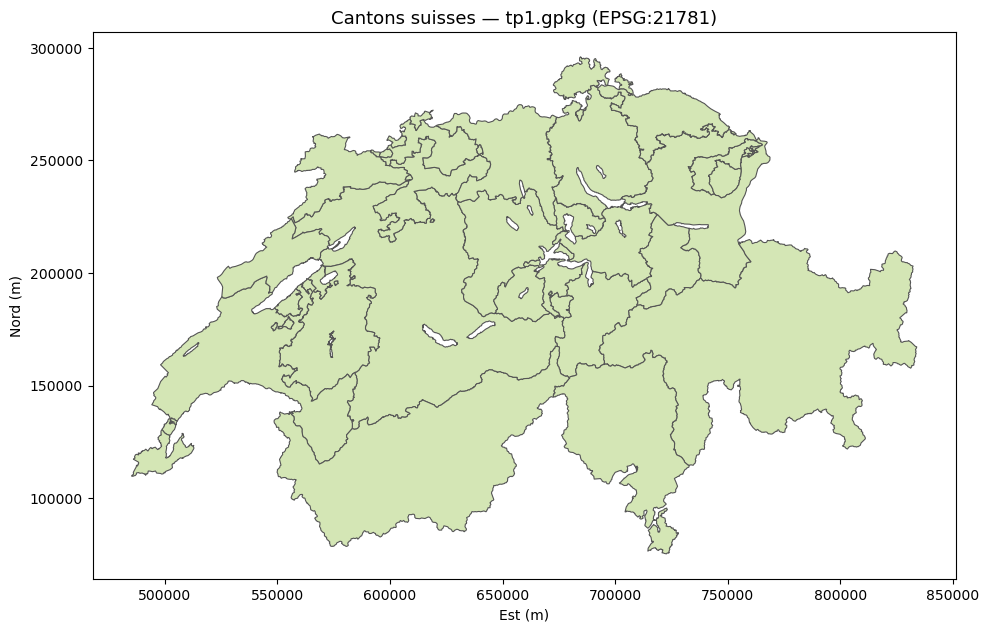

In [35]:
# --- Affichage simple avec .plot() ---
# Équivalent du rendu cartographique dans QGIS
fig, ax = plt.subplots(figsize=(10, 8))
cantons.plot(ax=ax, color='#d4e6b5', edgecolor='#555', linewidth=0.8)
ax.set_title('Cantons suisses — tp1.gpkg (EPSG:21781)', fontsize=13)
ax.set_xlabel('Est (m)')
ax.set_ylabel('Nord (m)')
plt.tight_layout()
plt.show()


/tmp/ipykernel_472240/481605653.py:15: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='lower right')


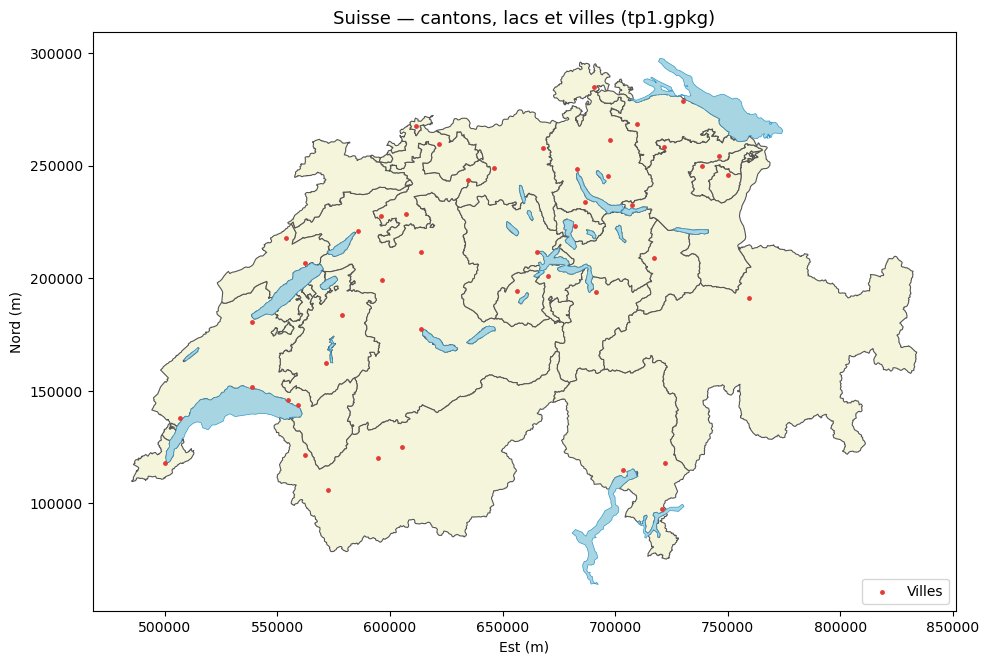

In [36]:
# --- Affichage multi-couches (comme superposer des couches dans QGIS) ---
# Chargement de plusieurs couches du même GeoPackage
towns = gpd.read_file('tp1.gpkg', layer='Towns')
lakes = gpd.read_file('tp1.gpkg', layer='Lakes')

fig, ax = plt.subplots(figsize=(10, 8))

# On superpose les couches dans le même ordre que le panneau "Couches" de QGIS :
# cantons en fond, puis lacs, puis villes au-dessus
cantons.plot(ax=ax, color='#f5f5dc', edgecolor='#555', linewidth=0.8, label='Cantons')
lakes.plot(ax=ax, color='#a8d5e2', edgecolor='#3399cc', linewidth=0.5, label='Lacs')
towns.plot(ax=ax, color='#e53935', markersize=6, label='Villes')

ax.set_title("Suisse — cantons, lacs et villes (tp1.gpkg)", fontsize=13)
ax.legend(loc='lower right')
ax.set_xlabel('Est (m)')
ax.set_ylabel('Nord (m)')
plt.tight_layout()
plt.show()


---
## 5. Parallèle QGIS ↔ Python

Voici un résumé des opérations que tu as effectuées dans QGIS au TP1 et leur équivalent en Python/GeoPandas :

| Opération dans QGIS (TP1) | Équivalent Python/GeoPandas |
|---|---|
| Ouvrir une couche de `tp1.gpkg` | `gpd.read_file("tp1.gpkg", layer="Cantons")` |
| Table attributaire | `gdf.head()` / `gdf[['NAME', 'area']]` |
| Sélection par attribut | `gdf[gdf['Population'] > 50000]` |
| SCR affiché en bas de QGIS | `gdf.crs` → `EPSG:21781` |
| Reprojection (Raster > Projections) | `gdf.to_crs(epsg=2056)` |
| Symbologie (couleur, épaisseur) | `gdf.plot(color=..., edgecolor=..., linewidth=...)` |
| Étiquettes (nom des villes) | `ax.annotate(row['ID1'], ...)` |
| Superposition de couches | Appels `.plot(ax=ax, ...)` successifs |
| Sauvegarder une couche | `gdf.to_file("sortie.gpkg", layer="Cantons")` |
| Field Calculator (longueur, surface) | `gdf.geometry.length` / `gdf.geometry.area` |

**Avantages de Python vs QGIS** :
- **Reproductibilité** : un script peut être relancé sur de nouvelles données sans refaire les clics
- **Automatisation** : traitement en lot de centaines de fichiers
- **Intégration** : combinaison avec NumPy, Pandas, Scikit-learn, etc.
- **Partage** : un notebook peut être partagé et exécuté par n'importe qui


In [37]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Chargement (= ouverture d'une couche dans QGIS)
towns = gpd.read_file('tp1.gpkg', layer='Towns')
print(f"Couche chargée : {towns.shape[0]} entités, CRS = {towns.crs.to_epsg()}")
print()


Couche chargée : 47 entités, CRS = 21781



Villes chargées : 47 entités, CRS = 21781

Aperçu des attributs (couche Towns) :
          ID1  Population  Rank
0      Horgen       18443     3
1       Uster       31954     2
2  Winterthur       99377     2
3      Zürich      368677     1
4        Bern      123466     1

Villes de plus de 50 000 habitants : 10
       ID1  Population
    Zürich      368677
    Genève      185958
     Basel      166173
  Lausanne      125885
      Bern      123466
Winterthur       99377
 St.Gallen       72642
    Luzern       59509
    Lugano       55060
      Biel       50455


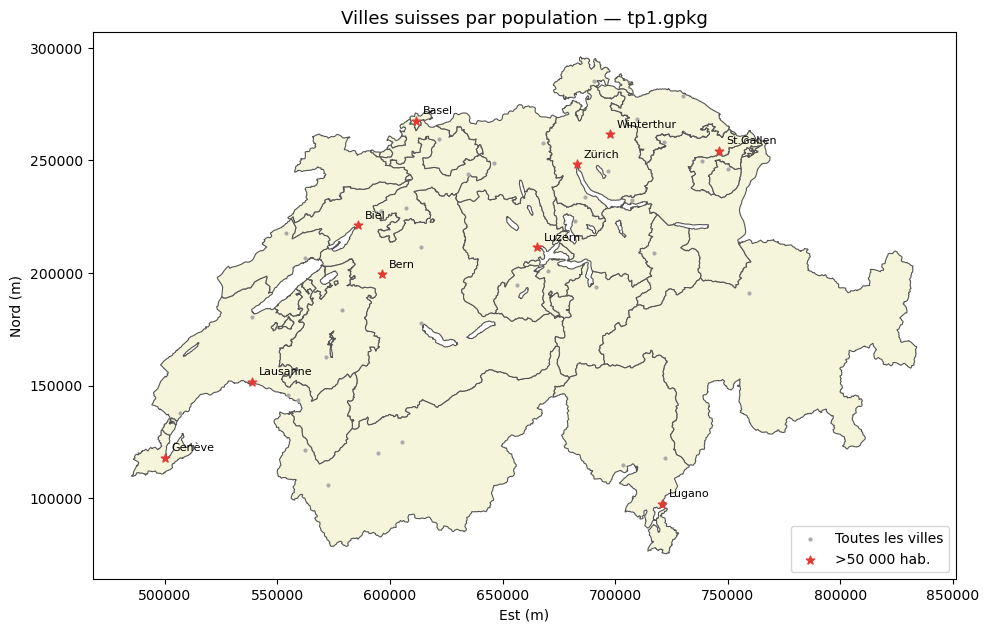

In [39]:
# Démonstration du workflow complet :
# charger → explorer → filtrer → visualiser
# (les mêmes étapes que dans QGIS au TP1, mais en Python !)

import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Chargement (= ouvrir les couches depuis tp1.gpkg dans QGIS)
towns   = gpd.read_file('tp1.gpkg', layer='Towns')
cantons = gpd.read_file('tp1.gpkg', layer='Cantons')
print(f"Villes chargées : {towns.shape[0]} entités, CRS = {towns.crs.to_epsg()}")

# 2. Exploration (= consulter la table attributaire dans QGIS)
print("\nAperçu des attributs (couche Towns) :")
print(towns[['ID1', 'Population', 'Rank']].head())

# 3. Filtrage (= sélection par attribut dans QGIS)
grandes_villes = towns[towns['Population'] > 50000]
print(f"\nVilles de plus de 50 000 habitants : {len(grandes_villes)}")
print(grandes_villes[['ID1', 'Population']].sort_values('Population', ascending=False).to_string(index=False))

# 4. Visualisation (= rendu cartographique dans QGIS)
fig, ax = plt.subplots(figsize=(10, 8))
cantons.plot(ax=ax, color='#f5f5dc', edgecolor='#555', linewidth=0.8)
towns.plot(ax=ax, color='#aaa', markersize=4, label='Toutes les villes')
grandes_villes.plot(ax=ax, color='#e53935', markersize=40,
                    marker='*', label='>50 000 hab.')

# Étiquettes des grandes villes (≡ onglet Étiquettes dans QGIS)
for _, row in grandes_villes.iterrows():
    ax.annotate(row['ID1'], xy=(row.geometry.x, row.geometry.y),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

ax.set_title('Villes suisses par population — tp1.gpkg', fontsize=13)
ax.legend(loc='lower right')
ax.set_xlabel('Est (m)')
ax.set_ylabel('Nord (m)')
plt.tight_layout()
plt.show()
